# The Challenge
<b> The sinking of the Titanic is one of the most infamous shipwrecks in history.On April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic sank after colliding with an iceberg. Unfortunately, there weren’t enough lifeboats for everyone onboard, resulting in the death of 1502 out of 2224 passengers and crew.While there was some element of luck involved in surviving, it seems some groups of people were more likely to survive than others.In this challenge, we ask you to build a predictive model that answers the question: “what sorts of people were more likely to survive?” using passenger data (ie name, age, gender, socio-economic class, etc) </b>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
# Scalers
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle

# Models
from sklearn.linear_model import LogisticRegression #logistic regression
from sklearn.linear_model import Perceptron
from sklearn import svm #support vector Machine
from sklearn.ensemble import RandomForestClassifier #Random Forest
from sklearn.neighbors import KNeighborsClassifier #KNN
from sklearn.naive_bayes import GaussianNB #Naive bayes
from sklearn.tree import DecisionTreeClassifier #Decision Tree
from sklearn.model_selection import train_test_split #training and testing data split
from sklearn import metrics #accuracy measure
from sklearn.metrics import confusion_matrix #for confusion matrix
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neural_network import MLPClassifier

# Cross-validation
from sklearn.model_selection import KFold #for K-fold cross validation
from sklearn.model_selection import cross_val_score #score evaluation
from sklearn.model_selection import cross_val_predict #prediction
from sklearn.model_selection import cross_validate

# GridSearchCV
from sklearn.model_selection import GridSearchCV

#Common Model Algorithms
from sklearn import svm, tree, linear_model, neighbors, naive_bayes, ensemble, discriminant_analysis, gaussian_process

#Common Model Helpers
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn import feature_selection
from sklearn import model_selection
from sklearn import metrics

#Visualization
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import seaborn as sns
import plotly.offline as py
py.init_notebook_mode(connected=True)
import plotly.graph_objs as go
import plotly.tools as tls
import plotly.figure_factory as ff
import plotly.express as px
import plotly.io as pio
pio.templates.default = "plotly_dark"
data_dir = '../input/titanic/'
os.listdir(data_dir)

['train.csv', 'gender_submission.csv', 'test.csv']

In [2]:
data = pd.read_csv(data_dir+'train.csv')
test_df = pd.read_csv(data_dir+'test.csv')
df = data.append(test_df) # The entire data: train + test.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1309 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
dtypes: float64(3), int64(4), object(5)
memory usage: 132.9+ KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,1309.000000,891.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000
mean,655.000000,0.383838,2.294882,29.881138,0.498854,0.385027,33.295479
std,378.020061,0.486592,0.837836,14.413493,1.041658,0.865560,51.758668
min,1.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,328.000000,0.000000,2.000000,21.000000,0.000000,0.000000,7.895800
50%,655.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,982.000000,1.000000,3.000000,39.000000,1.000000,0.000000,31.275000
max,1309.000000,1.000000,3.000000,80.000000,8.000000,9.000000,512.329200


In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## *  Exploratory Data Analysis *

In [6]:
print('Rows     :',df.shape[0])
print('Columns  :',df.shape[1])
print('\nFeatures :\n     :',df.columns.tolist())
print('\nMissing values    :',df.isnull().values.sum())
print('\nUnique values :  \n',df.nunique())

Rows     : 1309
Columns  : 12

Features :
     : ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Missing values    : 1698

Unique values :  
 PassengerId    1309
Survived          2
Pclass            3
Name           1307
Sex               2
Age              98
SibSp             7
Parch             8
Ticket          929
Fare            281
Cabin           186
Embarked          3
dtype: int64


In [7]:
df['Embarked'].value_counts()


S    914
C    270
Q    123
Name: Embarked, dtype: int64

In [8]:
M = df[(df['Embarked'] == 'S')]
B = df[(df['Embarked'] == 'C')]
K  = df[(df['Embarked'] == 'Q')]

trace = go.Bar(x = (len(M), len(B),len(K)), y = ['S','C','Q'], orientation = 'h', opacity = 0.8, marker=dict(
        color=['red','green','blue'],
        line=dict(color='#000000',width=1.5)))

layout = dict(title =  'Count of target variable')
                    
fig = dict(data = [trace], layout=layout)
py.iplot(fig)

In [9]:
labels = data['Sex'].value_counts()[:10].index
values = data['Embarked'].value_counts()[:10].values
colors=['#2678bf','#98adbf']

fig = go.Figure(data=[go.Pie(labels=labels, values=values, textinfo='label+percent',
                             insidetextorientation='radial',marker=dict(colors=colors))])
fig.show()

In [10]:
fig = px.scatter(data, x="Age", y="Fare", color="Survived", facet_col="Survived",
           color_continuous_scale=px.colors.sequential.Viridis, render_mode="webgl")
fig.show()

In [11]:
fig = px.scatter(data, x="Age", y="Fare", color="Sex", facet_col="Sex",
           color_continuous_scale=px.colors.sequential.Viridis, render_mode="webgl")
fig.show()

In [12]:
data_to_plot = data.dropna()
fig = px.violin(data_to_plot, y="Fare", x="Embarked", color="Embarked", box=True, points="all")
fig.show()

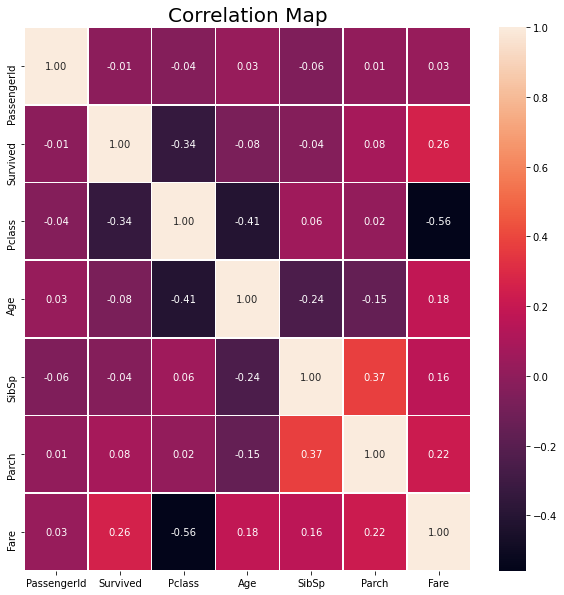

In [13]:
#correlation map
f, ax = plt.subplots(figsize=(10,10))
sns.heatmap(df.corr(), annot=True, linewidth=".5", fmt=".2f", ax = ax)
plt.title("Correlation Map",fontsize=20)
plt.show()

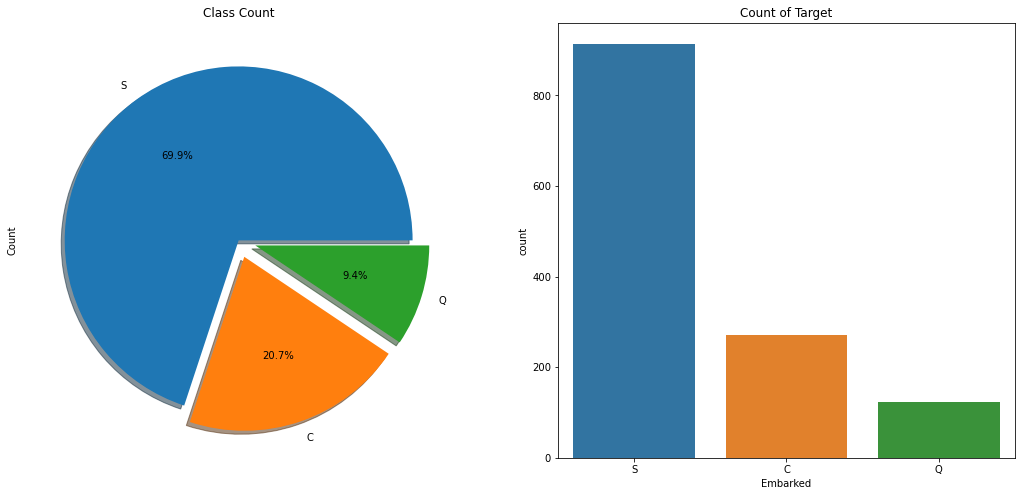

In [14]:
f,ax=plt.subplots(1,2,figsize=(18,8))
df['Embarked'].value_counts().plot.pie(explode=[0,0.1,0.1],autopct='%1.1f%%',ax=ax[0],shadow=True)
ax[0].set_title('Class Count')
ax[0].set_ylabel('Count')
sns.countplot('Embarked',data=df,ax=ax[1],order=df['Embarked'].value_counts().index)
ax[1].set_title('Count of Target')
plt.show()

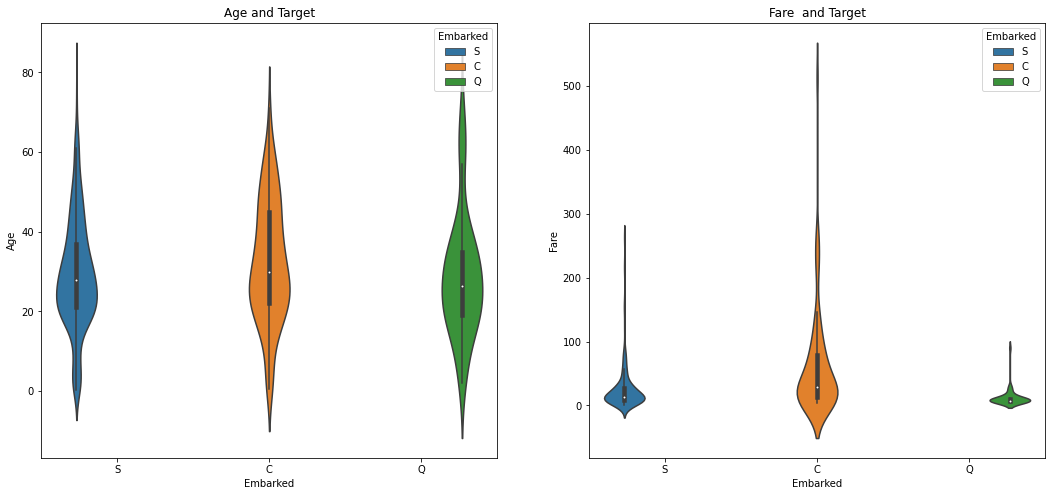

In [15]:
f,ax=plt.subplots(1,2,figsize=(18,8))
sns.violinplot("Embarked","Age", hue="Embarked", data=df,ax=ax[0])
ax[0].set_title('Age and Target')
sns.violinplot("Embarked","Fare", hue="Embarked", data=df,ax=ax[1])
ax[1].set_title('Fare  and Target')
plt.show()

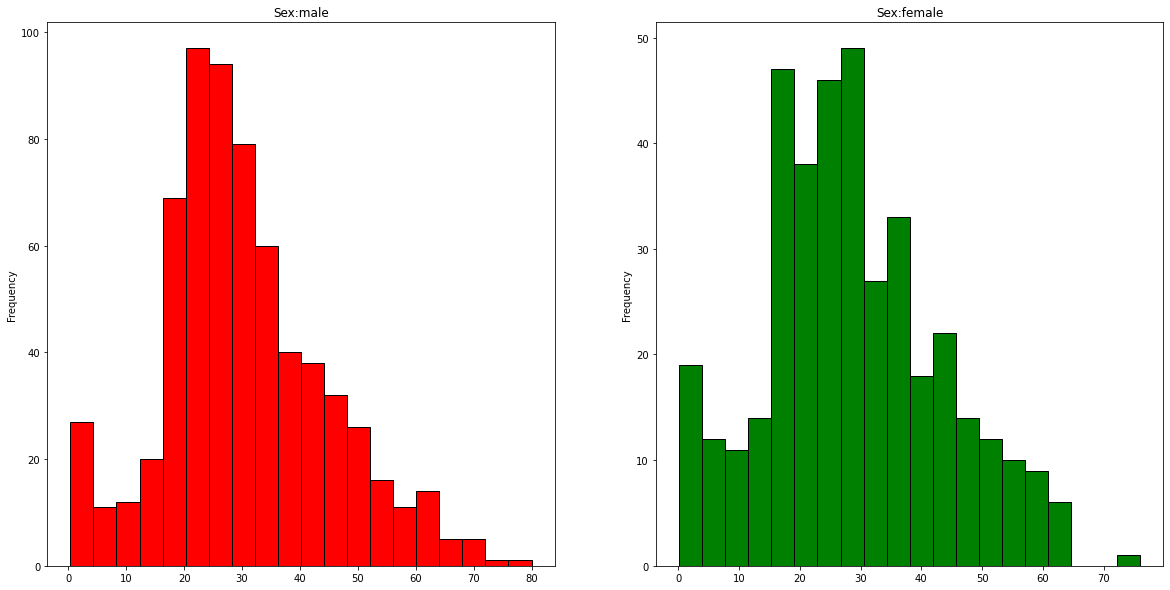

In [16]:
f,ax=plt.subplots(1,2,figsize=(20,10))
df[df['Sex']=='male'].Age.plot.hist(ax=ax[0],bins=20,edgecolor='black',color='red')
ax[0].set_title('Sex:male')

df[df['Sex']=='female'].Age.plot.hist(ax=ax[1],color='green',bins=20,edgecolor='black')
ax[1].set_title('Sex:female')

plt.show()

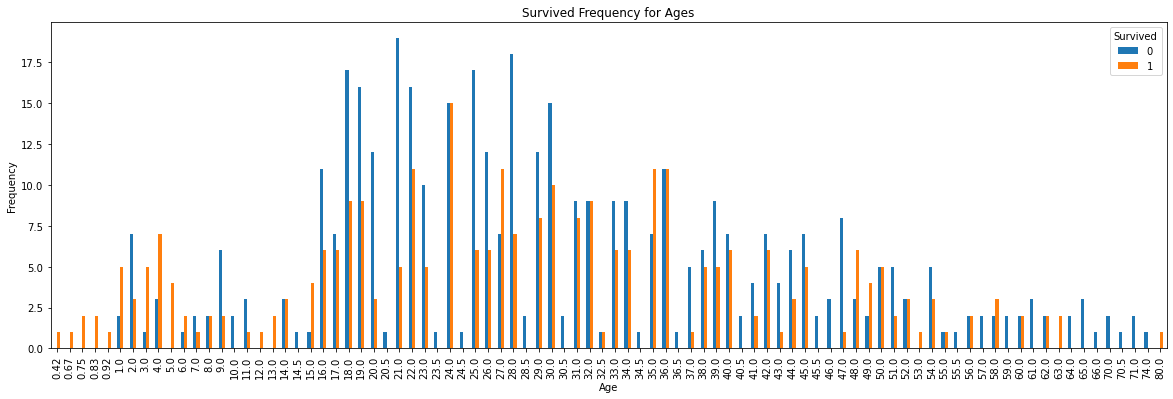

In [17]:
pd.crosstab(data.Age,data.Survived).plot(kind="bar",figsize=(20,6))
plt.title('Survived Frequency for Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

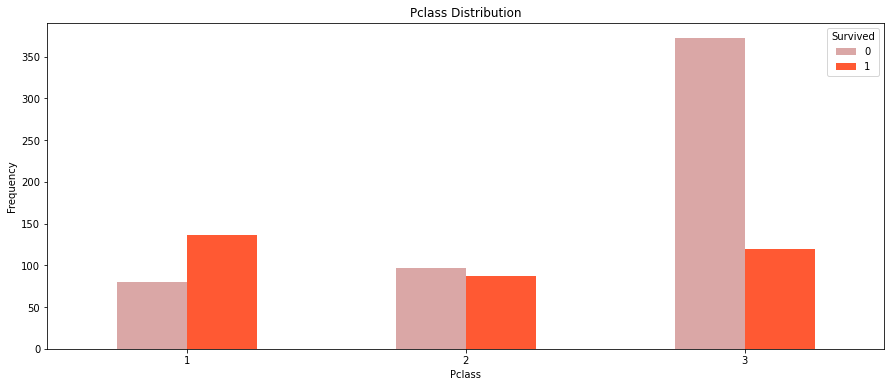

In [18]:
pd.crosstab(data.Pclass,data.Survived).plot(kind="bar",figsize=(15,6),color=['#DAA7A6','#FF5933' ])
plt.title('Pclass Distribution')
plt.xlabel('Pclass')
plt.xticks(rotation = 0)
plt.ylabel('Frequency')
plt.show()


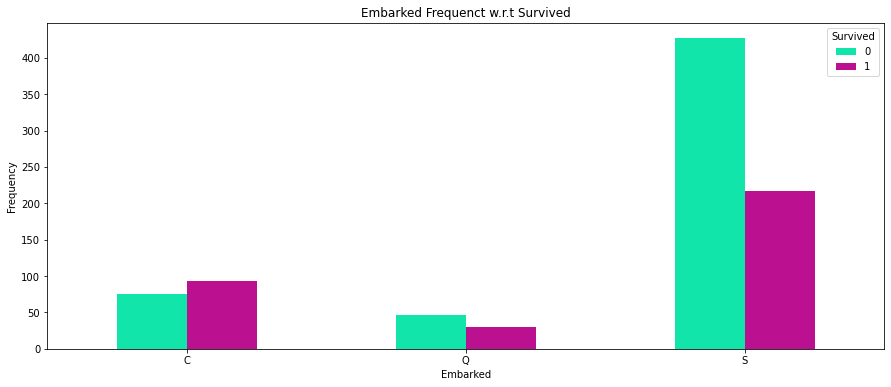

In [19]:
pd.crosstab(data.Embarked,data.Survived).plot(kind="bar",figsize=(15,6),color=['#11E5AA','#BB1190' ])
plt.title('Embarked Frequenct w.r.t Survived')
plt.xlabel('Embarked')
plt.xticks(rotation = 0)
plt.ylabel('Frequency')
plt.show()

## * Feature Engineering *

In [20]:
data['Sex'].replace(['male','female'],[0,1],inplace=True)
test_df['Sex'].replace(['male','female'],[0,1],inplace=True)

In [21]:
df['Fare'].fillna(df['Fare'].median(), inplace = True)

# Making Bins
df['FareBin'] = pd.qcut(df['Fare'], 5)

label = LabelEncoder()
df['FareBin_Code'] = label.fit_transform(df['FareBin'])

data['FareBin_Code'] = df['FareBin_Code'][:891]
test_df['FareBin_Code'] = df['FareBin_Code'][891:]

data.drop(['Fare'], 1, inplace=True)
test_df.drop(['Fare'], 1, inplace=True)

In [22]:
df['Age'].fillna(df['Fare'].median(), inplace = True)

df['AgeBin'] = pd.qcut(df['Age'], 4)

label = LabelEncoder()
df['AgeBin_Code'] = label.fit_transform(df['AgeBin'])

data['AgeBin_Code'] = df['AgeBin_Code'][:891]
test_df['AgeBin_Code'] = df['AgeBin_Code'][891:]

data.drop(['Age'], 1, inplace=True)
test_df.drop(['Age'], 1, inplace=True)

In [23]:
data['fam_count'] = data['SibSp']+data['Parch']
test_df['fam_count'] = test_df['SibSp']+test_df['Parch']

size = {
    0:'alone',
    1:'small',
    2:'small',
    3:'small',
    4:'large',
    5:'large',
    6:'large',
    7:'large',
    10:'large'
}

data['family_size'] = data['fam_count'].map(size)
test_df['family_size'] = test_df['fam_count'].map(size)

In [24]:
def create_dummies(df, column_name):
    dummies = pd.get_dummies(df[column_name], prefix=column_name)
    df = pd.concat([df,dummies],axis=1)
    df.drop(column_name, axis=1, inplace=True)
    return df

In [25]:
data = create_dummies(data,'Embarked')
data = create_dummies(data,'Pclass')
data = create_dummies(data,'family_size')

In [26]:
test_df = create_dummies(test_df,'Embarked')
test_df = create_dummies(test_df,'Pclass')
test_df = create_dummies(test_df,'family_size')

In [27]:
df_test = test_df.copy()

In [28]:
data.head()

,PassengerId,Survived,Name,Sex,SibSp,Parch,Ticket,Cabin,FareBin_Code,AgeBin_Code,fam_count,Embarked_C,Embarked_Q,Embarked_S,Pclass_1,Pclass_2,Pclass_3,family_size_alone,family_size_large,family_size_small
0,1,0,"Braund, Mr. Owen Harris",0,1,0,A/5 21171,NaN,0,1,1,0,0,1,0,0,1,0,0,1
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,1,0,PC 17599,C85,4,3,1,1,0,0,1,0,0,0,0,1
2,3,1,"Heikkinen, Miss. Laina",1,0,0,STON/O2. 3101282,NaN,1,2,0,0,0,1,0,0,1,1,0,0
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,1,0,113803,C123,4,2,1,0,0,1,1,0,0,0,0,1
4,5,0,"Allen, Mr. William Henry",0,0,0,373450,NaN,1,2,0,0,0,1,0,0,1,1,0,0


In [29]:
data.drop(['Name', 'PassengerId', 'Ticket', 'Cabin'], axis = 1, inplace = True)
test_df.drop(['Name','PassengerId', 'Ticket', 'Cabin'], axis = 1, inplace = True)

In [30]:
def get_X_and_y(dataset, target_name):
    X=dataset.drop(target_name, axis=1)
    y=dataset[target_name]
    sc = StandardScaler()
    X=sc.fit_transform(X)    
    return X, y

In [31]:
X,y = get_X_and_y(data,target_name='Survived')

## * Predictive Model *

In [32]:
model = RandomForestClassifier(n_estimators = 100, max_depth = 5,random_state = 1)
model.fit(X,y)
predictions = model.predict(test_df)

output = pd.DataFrame({'PassengerId': df_test.PassengerId, 'Survived': predictions})
output.to_csv('my_submission.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!
